```yaml
---
title: "Scrum: Points and Counterpoint"
date: 2026-01-23 11:37:00 -0500
categories:
  - architecture
  - sdlc
  - software engineering
  - agile
  - kanban
  - scrum  
author: steven
---
```

<img src="https://raw.githubusercontent.com/git-steven/git-steven.github.io/master/assets/images/scrum-counterpoints.png" width="600"/>

# Scrum: Points and Counterpoint

## 📖 Table of Contents
- [📍 When Velocity Becomes the Target](#-when-velocity-becomes-the-target)
- [🧬 When Complexity Compounds](#-when-complexity-compounds)
- [📐️ When the Framework Doesn't Fit](#-when-the-framework-doesnt-fit)
- [🤔 Expectation vs. Reality](#-expectation-vs-reality)
- [🗝️ Key takeaways](#-key-takeaways)
- [📚 References & Further Reading](#-references--further-reading)

---
## 🌀 Introduction

_Welcome, fellow practitioners of software engineering. 🤓_

What follows is a modest examination of Scrum -- that beloved framework which has achieved near-liturgical status in parts of our industry.

Scrum promises predictable delivery through disciplined iteration.  
In practice, it often measures something else entirely:

### 💨 Motion rather than progress.
* Burndown charts fall  
* Velocity charts rise  
* Sprint boards clear 
* _**Meanwhile**, the architecture quietly accumulates complexity_

This essay explores several common failure modes—not because Scrum is uniquely flawed, but because **its incentives frequently reward the wrong behaviors.**

And incentives, as every systems engineer eventually learns, shape outcomes more reliably than intentions.

But let's establish scope first: **no development process—Scrum, Kanban, or otherwise—is a substitute for sound engineering practice.**

___

## 📍 When Velocity Becomes the Target
> 🤓 **Nerdy Aside:** These dysfunction patterns have a name: **_Goodhart's Law_**.
> As Marilyn Strathern generalized it: *"When a measure becomes a target, it ceases to be a good measure."*[^2]

The moment velocity becomes the metric by which teams are judged, velocity becomes what teams optimize for—not value, not quality, not problems solved.

 🗺️ _The map eats the territory._

### 📉️ The Ever-Lowering Bar

In an effort to meet Scrum's lofty goals, teams often find themselves setting the bar lower and lower with each sprint. Before you know it, you're celebrating the completion of tasks like "update the README file" and "fix a typo in the comments." Talk about aiming high!

### 🎭 The Ticket Selection Dance

As a sprint progresses, developers start eyeing tickets they think can be finished before the sprint ends, rather than tackling the most important tasks. It's like choosing to do the dishes instead of studying for a final exam—sure, it feels productive, but is it the best use of your time?

Lean practitioners call this *local optimization*—optimizing for the sprint metric at the expense of system-wide value.[^3] The incentive structure is clear: finishing a small ticket feels good and "counts." Starting an important but uncertain ticket risks rollover. Rational actors respond to incentives. The sprint boundary *is* the incentive.

---

## 🧬 When Complexity Compounds

### 🏦 The Entropy Tax

Here's a pattern my colleagues and I have observed repeatedly: a significant portion of sprint work traces back to fixing bugs from *earlier* tickets. 
* **Sprint 3:** Feature **A** ships  
* **Sprint 5:** "Fix edge case in Feature **A**"  
* **Sprint 7:** "Refactor Feature **A** for performance"  
* **Sprint 9:** "Address security vulnerability introduced by Feature **A** refactor"

> 🧬 This is the "entropy tax" -- the inevitable cost of adding features to a codebase with increasing complexity. Scrum's sprint structure obscures this by treating each ticket as independent, when they're actually nodes in a dependency graph that only grows more tangled. 

The velocity chart says 40 points per sprint. 

The codebase knows the truth.

#### 🌫️ Forward Momentum?
Story points create an illusion of forward momentum--the board clears, the burndown trends toward zero, stakeholders nod approvingly--while the product quietly drifts further into entropy. As Ron Jeffries observed of teams under sprint pressure: *"They skimped on testing. They skimped on design."*[^8]

This pattern illustrates a deeper mismatch between Scrum’s metrics and software reality.

* Velocity measures **completed tickets**.
* Software quality depends on **architectural state**
* Those two quantities are only loosely correlated.
* A team can maintain perfectly stable velocity while the system itself becomes steadily more fragile.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


### Notebook Figure 1 — Velocity vs. Architectural Health

This figure is inserted exactly where the essay pivots from **completed tickets** to **architectural state**. The point is not “Scrum always causes this,” but that a team can move **rightward on local throughput** while drifting **downward on structural health** if the process emphasizes motion over maintainability.


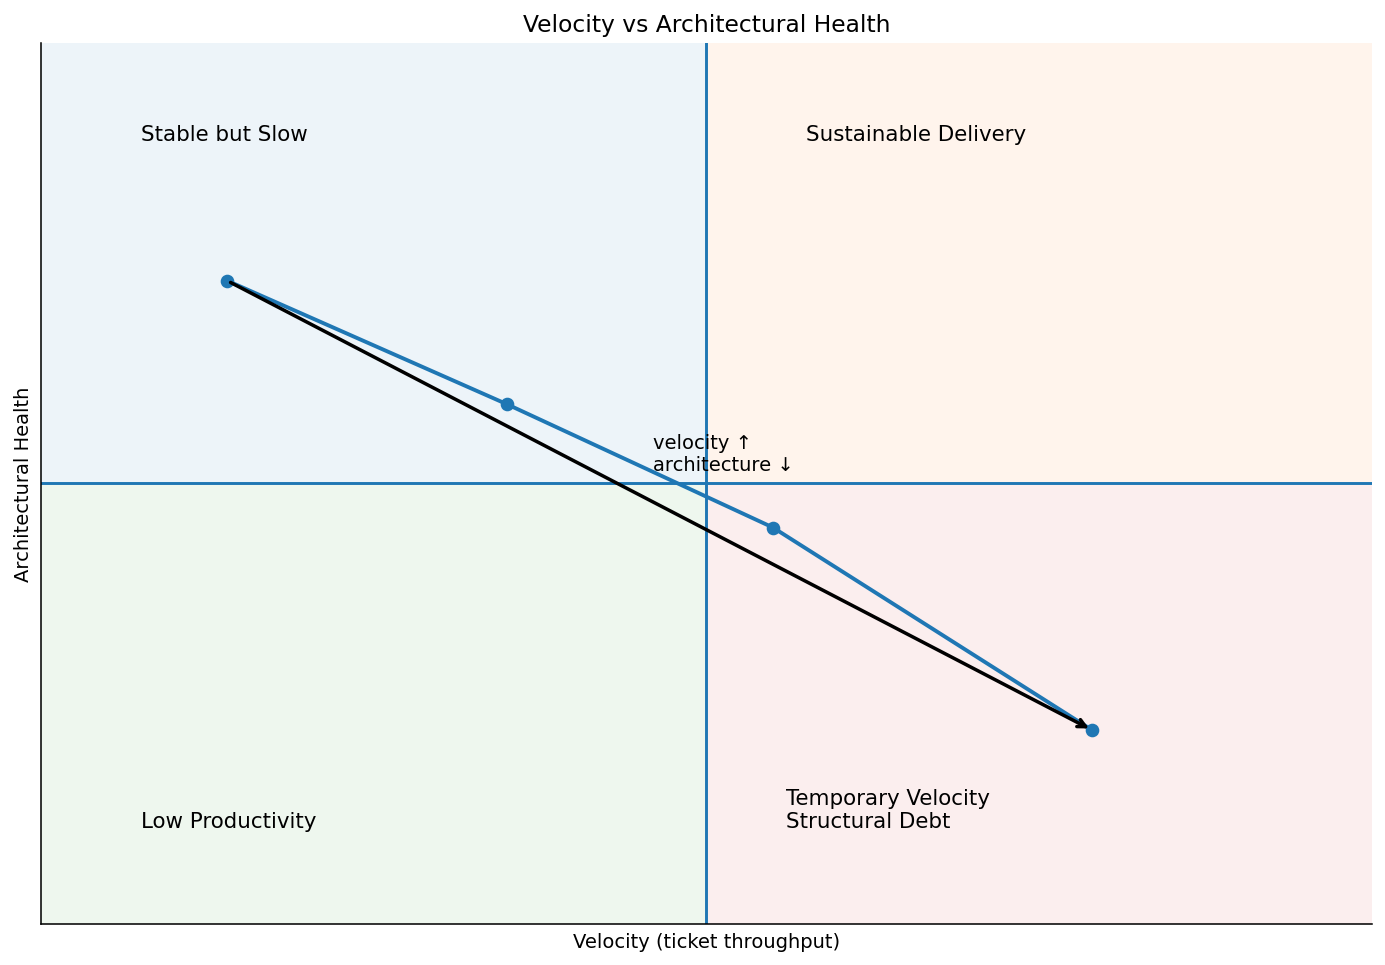

In [3]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.axhline(0, linewidth=1.5)
ax.axvline(0, linewidth=1.5)

ax.fill_between([-1, 0], 0, 1, alpha=0.08)
ax.fill_between([0, 1], 0, 1, alpha=0.08)
ax.fill_between([-1, 0], -1, 0, alpha=0.08)
ax.fill_between([0, 1], -1, 0, alpha=0.08)

ax.text(-0.85, 0.78, "Stable but Slow", fontsize=11)
ax.text(0.15, 0.78, "Sustainable Delivery", fontsize=11)
ax.text(-0.85, -0.78, "Low Productivity", fontsize=11)
ax.text(0.12, -0.78, "Temporary Velocity\nStructural Debt", fontsize=11)

x = np.array([-0.72, -0.30, 0.10, 0.58])
y = np.array([ 0.46,  0.18,-0.10,-0.56])

ax.plot(x, y, marker="o", linewidth=2)

ax.annotate(
    "",
    xy=(x[-1], y[-1]),
    xytext=(x[0], y[0]),
    arrowprops=dict(arrowstyle="->", linewidth=1.8),
)

ax.text(-0.08, 0.03, "velocity ↑\narchitecture ↓", fontsize=10)

ax.set_title("Velocity vs Architectural Health")
ax.set_xlabel("Velocity (ticket throughput)")
ax.set_ylabel("Architectural Health")

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()


### 🧟 Backlog Purgatory

Unfinished tickets get ceremoniously moved to the next sprint, creating a never-ending cycle of rollover. It's like Groundhog Day, but instead of Bill Murray, it's exhausted developers wondering if they'll ever see the light at the end of the backlog.

The backlog becomes a graveyard of good intentions. Practitioners observe that 30-70% of backlog items are never implemented.[^4] These "zombie tickets" shamble along indefinitely: too politically sensitive to delete, too stale to prioritize.

---

## 📐️ When the Framework Doesn't Fit

### ∞ The CI/CD Paradox

Scrum assumes work is naturally organized into fixed-length iterations.

Modern delivery systems assume the opposite.

Continuous Integration and Continuous Deployment encourage **small, constant releases**. Work flows through the system continuously rather than in batches.

If a team deploys ten times per day, the sprint boundary stops describing how software moves through the system.

It becomes an administrative artifact.

At that point it resembles placing mile markers on a river .

🌊 The water flows regardless.


### Notebook Figure 2 — Temporary Velocity, Structural Debt

This second figure shows the longer arc: early throughput can improve while technical entropy accumulates quietly underneath. Eventually the system hits a cost-of-change wall, and the apparent productivity win turns into drag, rework, and fragility.


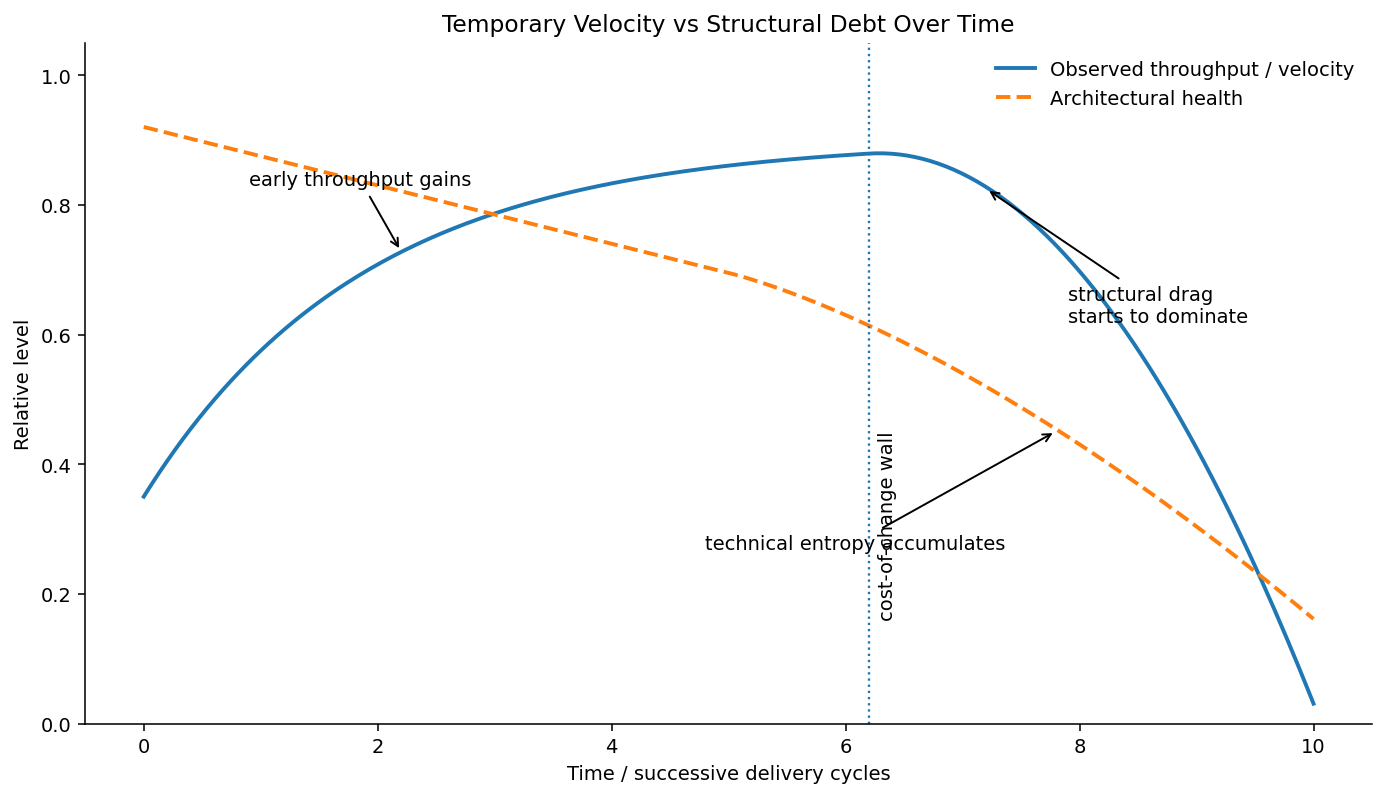

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.8))

t = np.linspace(0, 10, 300)

velocity = 0.35 + 0.55 * (1 - np.exp(-t / 1.9)) - 0.06 * np.maximum(t - 6.2, 0) ** 2
architecture = 0.92 - 0.045 * t - 0.02 * np.maximum(t - 5.0, 0) ** 1.7

ax.plot(t, velocity, linewidth=2, label="Observed throughput / velocity")
ax.plot(t, architecture, linewidth=2, linestyle="--", label="Architectural health")

ax.axvline(6.2, linewidth=1.2, linestyle=":")
ax.text(6.28, 0.16, "cost-of-change wall", fontsize=10, rotation=90, va="bottom")

ax.annotate(
    "early throughput gains",
    xy=(2.2, velocity[np.searchsorted(t, 2.2)]),
    xytext=(0.9, 0.83),
    arrowprops=dict(arrowstyle="->", linewidth=1.0),
    fontsize=10,
)

ax.annotate(
    "structural drag\nstarts to dominate",
    xy=(7.2, velocity[np.searchsorted(t, 7.2)]),
    xytext=(7.9, 0.62),
    arrowprops=dict(arrowstyle="->", linewidth=1.0),
    fontsize=10,
)

ax.annotate(
    "technical entropy accumulates",
    xy=(7.8, architecture[np.searchsorted(t, 7.8)]),
    xytext=(4.8, 0.27),
    arrowprops=dict(arrowstyle="->", linewidth=1.0),
    fontsize=10,
)

ax.set_title("Temporary Velocity vs Structural Debt Over Time")
ax.set_xlabel("Time / successive delivery cycles")
ax.set_ylabel("Relative level")
ax.set_ylim(0, 1.05)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


### 🔬 The Micromanaging Scrum Master

And let's not forget the well-meaning but often overbearing Scrum Master who turns daily stand-ups into interrogation sessions, demanding detailed explanations for every minute spent. Because nothing screams "agile" like justifying your bathroom breaks.

The problem isn't bad Scrum Masters—it's a role definition that conflates facilitation, coaching, and accountability. When "servant leadership" lacks clear boundaries, it devolves into status reporting with extra steps.

---

## 🤔 Expectation vs. Reality

| _Item_             | Expectation                       | Reality                               |
|--------------------|-----------------------------------|---------------------------------------|
| **Delivery**       | 📦 Predictable releases           | 📋 Predictable meetings               |
| **Priority**       | 📍 Focus on highest-value work    | 🧹 Focus on what fits in the sprint   |
| **Improvement**    | 🌱 Continuous growth              | 🧟 Continuous rollover                |
| **Autonomy**       | 🧩 Self-organizing teams          | 🔬 Daily status interrogations        |
| **Responsiveness** | 🌬️ Agility to shifting winds     | 🧊 Two-week batching cycles           |
| **Completion**     | ✅ Done means done                 | 📉️ Done means "moved to next sprint" |
| **Planning**       | 🧠 Right-sized work conversations | 🎰 Estimation poker theater           |
| **Metrics**        | 📊 Actionable flow data           | 🏃 Velocity as vanity metric          |

---

## 🗝️ Key takeaways

> *"Tell me how you measure me, and I will tell you how I will behave."* — Eliyahu M. Goldratt, *The Haystack Syndrome*[^6]

While Scrum has its merits, it's important to recognize its potential drawbacks. From lowering the bar to micromanagement, Scrum can do more harm than good. The research backs this up: the DORA metrics that actually predict software delivery performance—deployment frequency, lead time, change failure rate, and recovery time—have nothing to do with velocity.[^7]

So, the next time someone suggests implementing Scrum, consider if it's really the best fit—or if it's just another process trap in agile clothing. 🪤 If this resonates, consider Kanban--its WIP limits create space for architectural thinking rather than perpetual firefighting[^9], its explicit policies can reserve capacity for refactoring and tech-debt reduction[^9], and its flow-based measurement makes *failure demand* (rework caused by poor architecture) visible rather than burying it in the next sprint. Shape Up and simply... fewer meetings are worth exploring too. Your team's actual output will tell you what works.

Ultimately, process matters far less than engineering fundamentals:

- loose coupling  
- separation of concerns  
- evolutionary architecture

Frameworks do not create good software.

Engineers do.

Process can encourage those practices—or quietly undermine them.

Choose deliberately.

Class dismissed. There will be no retro. 🤓

---

> **⚖️ Fair Warning:** I've seen wonderful project managers working as Scrum Masters who weren't overbearing micromanagers. I've also seen good Scrum teams adjust their process and actually work in an agile fashion, delivering good software on time. However, I've seen the situation described in this article much more often. My personal preference is an actually agile Kanban process, modified for the engineering team and the type of software being built. But regardless of process choice, the real leverage is in engineering fundamentals--loose coupling, separation of concerns, evolutionary architecture[^10]. Process can encourage or discourage those practices; it cannot replace them. 🌊

---

## 📚 References & Further Reading

### Foundational Texts
- Beck, K. et al. (2001). [Manifesto for Agile Software Development](https://agilemanifesto.org/). *The original principles—notably silent on sprints, points, and ceremonies.*
- Schwaber, K. & Sutherland, J. (2020). [The Scrum Guide](https://scrumguides.org/). *The official framework—worth reading to see how far implementations have drifted.*

### Critiques & Alternatives
- Anderson, D. J. (2010). *Kanban: Successful Evolutionary Change for Your Technology Business*. Blue Hole Press. *The foundational text on flow-based development.*
- Jeffries, R. (2018). [Developers Should Abandon Agile](https://ronjeffries.com/articles/018-01ff/abandon-1/). *One of Agile's original signatories calls out what it's become.*
- Lei, H., Ganjeizadeh, F., Jayachandran, P. K., & Ozcan, P. (2015). [A statistical analysis of the effects of Scrum and Kanban on software development projects](https://doi.org/10.1016/j.rcim.2015.12.001). *Robotics and Computer-Integrated Manufacturing*, 43, 59–67. *Empirical evidence that Kanban outperforms Scrum on quality metrics.*
- Fowler, M. (2019). Foreword to *Building Evolutionary Architectures* (Ford, N., Parsons, R., & Kua, P.). O'Reilly Media. *Small, guided changes with continuous feedback loops—architecture as a living system.*

### On Measurement & Performance
- Forsgren, N., Humble, J., & Kim, G. (2018). *Accelerate: The Science of Lean Software and DevOps*. IT Revolution Press. *Research showing what actually drives performance (hint: not sprint velocity).*
- Goldratt, E. M. (1990). *The Haystack Syndrome: Sifting Information Out of the Data Ocean*. North River Press. *Source of the measurement quote—and essential reading on metrics dysfunction.*

---

### Footnotes

[^1]: Einstein's actual words, from his 1933 Herbert Spencer Lecture at Oxford: "The supreme goal of all theory is to make the irreducible basic elements as simple and as few as possible without having to surrender the adequate representation of a single datum of experience." The pithy paraphrase appeared decades later.

[^2]: Strathern, M. (1997). "'Improving ratings': audit in the British University system." *European Review*, Vol. 5, No. 3, pp. 305-321. This is the popular generalization of Goodhart's original 1975 formulation.

[^3]: See Reinertsen, D. G. (2009). *The Principles of Product Development Flow*. Celeritas Publishing. Chapter 3 covers local vs. global optimization in detail.

[^4]: This is practitioner observation rather than peer-reviewed research—a notable gap in the literature. The phenomenon of "backlog bankruptcy" (periodically deleting stale items) is widely recognized but understudied.

[^5]: Scrum was introduced at OOPSLA 1995, but the formal Scrum Guide document was first published in 2010 and has been updated in 2011, 2013, 2016, 2017, and 2020.

[^6]: Goldratt, E. M. (1990). *The Haystack Syndrome*, p. 26. Often misattributed to his more famous *The Goal* (1984).

[^7]: Forsgren et al.'s research, based on 23,000+ survey responses, found high performers deploy 200x more frequently with 106x faster lead times. Velocity was explicitly identified as an invalid productivity metric.

[^8]: Jeffries, R. (2018). "Dark Scrum"—a recurring theme in his writing: teams under sprint pressure routinely skip design and testing, accumulating debt that compounds across sprints. See [Dark Scrum](https://ronjeffries.com/articles/016-09ff/defense/).

[^9]: Anderson, D. J. (2010). *Kanban*, Chapters 4–8. Key concepts: WIP limits reduce design-in-progress and boost quality; failure demand (rework from defects) becomes a measurable flow category; Classes of Service allow explicit capacity reservation for tech debt and architectural work.

[^10]: Fowler, M. (2019). Foreword to *Building Evolutionary Architectures*: architectural integrity comes from small, guided changes with continuous feedback—not from any particular project management cadence. Lei et al. (2015) provide empirical support: Kanban's flow model correlates with higher quality outcomes than Scrum's time-boxed model.

[^11]: Lei, H. et al. (2015). "A statistical analysis of the effects of Scrum and Kanban on software development projects." *Robotics and Computer-Integrated Manufacturing*, 43, pp. 59–67. The study found statistically significant quality advantages for Kanban over Scrum across multiple project dimensions.
